Try using a denoising autoencoder to pretrain an image classifier. You
can use MNIST (the simplest option), or a more complex image dataset
such as CIFAR10 if you want a bigger challenge. Regardless of the
dataset you’re using, follow these steps

a. Split the dataset into a training set and a test set. Train a deep
denoising autoencoder on the full training set.

b. Check that the images are fairly well reconstructed. Visualize the
images that most activate each neuron in the coding layer.

c. Build a classification DNN, reusing the lower layers of the
autoencoder. Train it using only 500 images from the training set.
Does it perform better with or without pretraining?

In [7]:
%pip install tensorflow
%pip install numpy
%pip install matplotlib

In [8]:
!nvidia-smi -L
import tensorflow as tf
print("TF:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

GPU 0: NVIDIA H100 80GB HBM3 (UUID: GPU-50e95733-4597-e48f-b668-5a97fb2f67e5)
TF: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [9]:
from tensorflow.keras import mixed_precision

# Acelera en Tensor Cores (H100)
mixed_precision.set_global_policy("mixed_float16")
tf.config.optimizer.set_jit(True)  # XLA

gpus = tf.config.list_physical_devices("GPU")
strategy = tf.distribute.MirroredStrategy() if len(gpus) > 1 else tf.distribute.get_strategy()


El conjunto de datos CIFAR-10 consta de 60.000 imágenes a color de 32x32 en 10 clases, con 6.000 imágenes por clase. Hay 50.000 imágenes de entrenamiento y 10.000 imágenes de prueba.


In [10]:
import tensorflow as tf

dataset = tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [109]:
(x_train, y_train), (x_test, y_test) = dataset

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_val = x_train

print(x_train.shape)


(50000, 32, 32, 3)


In [111]:
print(x_train.shape)
print(x_val.shape)

(50000, 32, 32, 3)
(50000, 32, 32, 3)


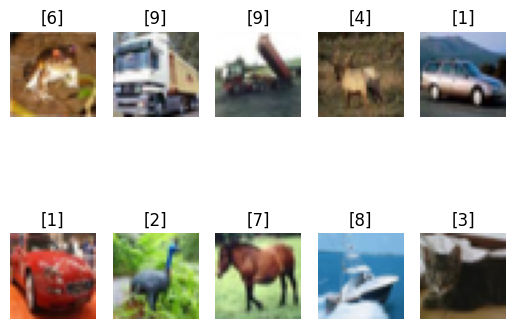

In [112]:
import matplotlib.pyplot as plt

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(y_train[i])
    plt.axis('off')
plt.show()

In [113]:
encoder = tf.keras.Sequential([
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(32 * 32 * 3, activation="relu"),
    tf.keras.layers.Dense(5000, activation="relu"),
    tf.keras.layers.Dense(4000, activation="relu"),
    tf.keras.layers.Dense(3000, activation="relu"),
    tf.keras.layers.Dense(2000, activation="relu"),
    tf.keras.layers.Dense(1000, activation="relu"),
    tf.keras.layers.Dense(500, activation="relu"),
    tf.keras.layers.Dense(200, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(50, activation="relu")
])

decoder = tf.keras.Sequential([
    tf.keras.layers.Dense(50, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(200, activation="relu"),
    tf.keras.layers.Dense(500, activation="relu"),
    tf.keras.layers.Dense(1000, activation="relu"),
    tf.keras.layers.Dense(2000, activation="relu"),
    tf.keras.layers.Dense(3000, activation="relu"),
    tf.keras.layers.Dense(4000, activation="relu"),
    tf.keras.layers.Dense(5000, activation="relu"),
    tf.keras.layers.Dense(32 * 32 * 3, activation="sigmoid"),
    tf.keras.layers.Reshape([32, 32, 3])
])

autoencoder = tf.keras.Sequential([encoder, decoder])

In [114]:
from tensorflow.python.data import AUTOTUNE
BATCH_SIZE = 128

def add_noise(x, sigma=0.5):
    noise = tf.random.normal(tf.shape(x), mean=0.0, stddev=sigma)
    return tf.clip_by_value(x + noise, 0.0, 1.0)

def make_ds(x, training=True):
    ds = tf.data.Dataset.from_tensor_slices(x)
    if training:
        ds = ds.shuffle(10000)
    ds = ds.map(lambda clean: (add_noise(clean), clean), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_ds(x_train, training=True)
val_ds   = make_ds(x_val, training=False)
test_ds  = make_ds(x_test, training=False)

In [115]:
with strategy.scope():
    autoencoder.compile(loss="binary_crossentropy", optimizer=tf.keras.optimizers.Adam(learning_rate=0.002))

history = autoencoder.fit(train_ds, validation_data=val_ds, epochs=125)

Epoch 1/125
391/391 ━━━━━━━━━━━━━━━━━━━━ 85s 147ms/step - loss: 0.6919 - val_loss: 0.6891
Epoch 2/125
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6892 - val_loss: 0.6891
Epoch 3/125
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6892 - val_loss: 0.6892
Epoch 4/125
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6891 - val_loss: 0.6891
Epoch 5/125
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6892 - val_loss: 0.6891
Epoch 6/125
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6891 - val_loss: 0.6891
Epoch 7/125
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6892 - val_loss: 0.6892
Epoch 8/125
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6892 - val_loss: 0.6891
Epoch 9/125
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6891 - val_loss: 0.6891
Epoch 10/125
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6891 - val_loss: 0.6891
Epoch 11/125
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6892 - val_loss: 0.6891
Epoch 12/125
391/391 ━━━━━━━━━━━━━━━━━

KeyboardInterrupt: 

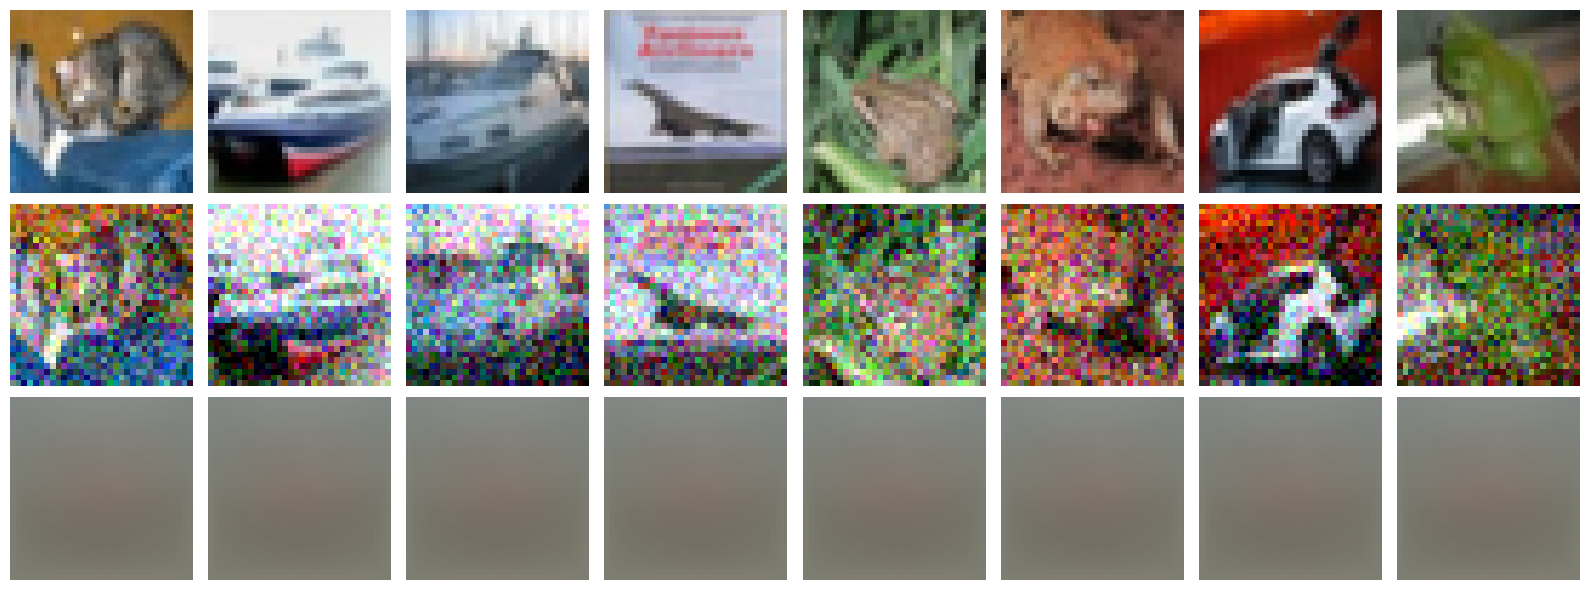

In [116]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

# Asegúrate de usar imágenes, no labels
(x_train, _), (x_test, _) = keras.datasets.cifar10.load_data()
x_test = x_test.astype("float32") / 255.0

n = 8
clean = x_test[:n]
noisy = tf.clip_by_value(clean + 0.15 * tf.random.normal(tf.shape(clean)), 0.0, 1.0)

denoised = autoencoder.predict(noisy, verbose=0)

# 👇 cast a float32 para matplotlib
clean = clean.astype(np.float32)
noisy = noisy.numpy().astype(np.float32)
denoised = denoised.astype(np.float32)

fig, ax = plt.subplots(3, n, figsize=(2*n, 6))
for i in range(n):
    ax[0, i].imshow(np.clip(clean[i], 0, 1));    ax[0, i].axis("off")
    ax[1, i].imshow(np.clip(noisy[i], 0, 1));    ax[1, i].axis("off")
    ax[2, i].imshow(np.clip(denoised[i], 0, 1)); ax[2, i].axis("off")
plt.tight_layout()
plt.show()


In [117]:


def build_dae():
    inp = keras.Input(shape=(32, 32, 3))
    x = tf.keras.layers.Conv2D(32, 3, strides=2, padding="same", activation="relu")(inp)
    x = tf.keras.layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(x)
    x = tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu")(x)

    x = tf.keras.layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(x)
    x = tf.keras.layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(x)
    out = tf.keras.layers.Conv2D(3, 3, padding="same", activation="sigmoid")(x)
    return tf.keras.Model(inp, out, name="dae_cifar10")

with strategy.scope():
    model = build_dae()
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
    ]
)

Epoch 1/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - loss: 0.0282 - val_loss: 0.0124
Epoch 2/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0122 - val_loss: 0.0115
Epoch 3/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0114 - val_loss: 0.0111
Epoch 4/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0109 - val_loss: 0.0106
Epoch 5/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0106 - val_loss: 0.0105
Epoch 6/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0105 - val_loss: 0.0103
Epoch 7/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0103 - val_loss: 0.0102
Epoch 8/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0103 - val_loss: 0.0101
Epoch 9/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0102 - val_loss: 0.0102
Epoch 10/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0101 - val_loss: 0.0102
Epoch 11/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0100 - val_loss: 0.0101
Epoch 12/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/st

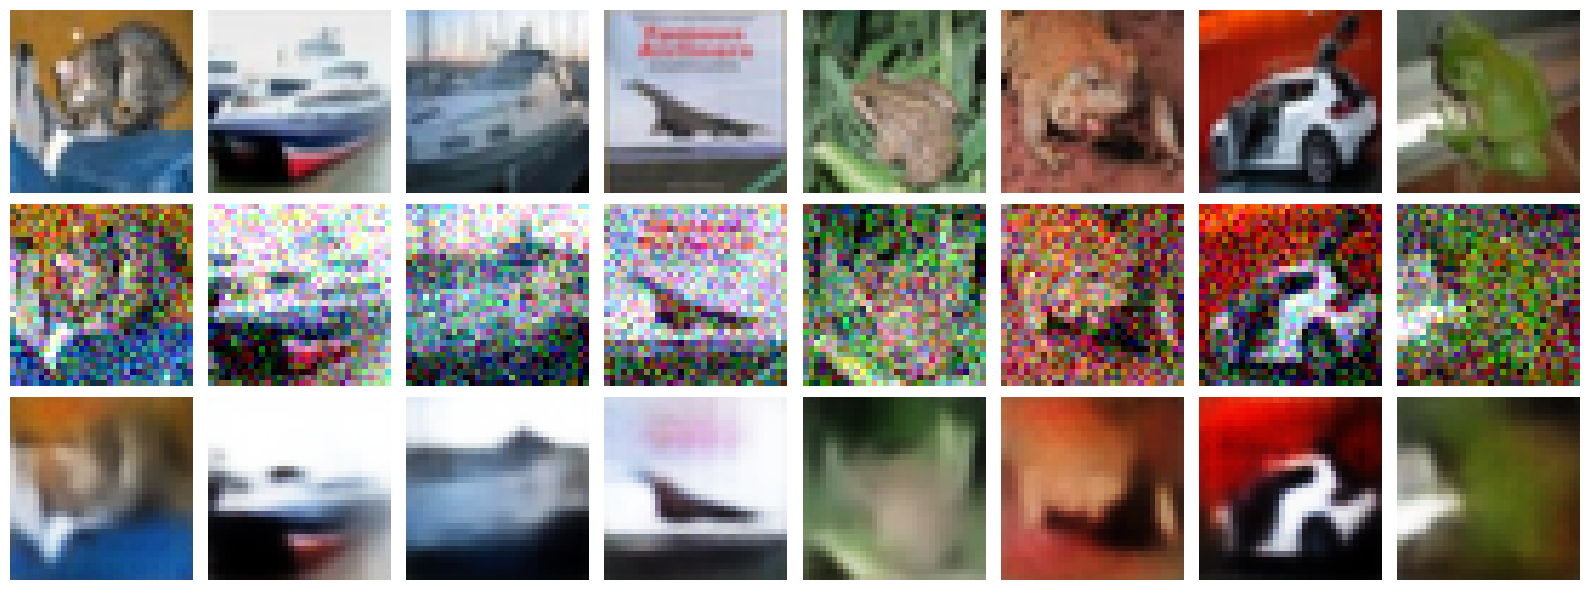

In [119]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

# Asegúrate de usar imágenes, no labels
(x_train, _), (x_test, _) = keras.datasets.cifar10.load_data()
x_test = x_test.astype("float32") / 255.0

n = 8
clean = x_test[:n]
noisy = tf.clip_by_value(clean + 0.15 * tf.random.normal(tf.shape(clean)), 0.0, 1.0)

denoised = model.predict(noisy, verbose=0)

# 👇 cast a float32 para matplotlib
clean = clean.astype(np.float32)
noisy = noisy.numpy().astype(np.float32)
denoised = denoised.astype(np.float32)

fig, ax = plt.subplots(3, n, figsize=(2*n, 6))
for i in range(n):
    ax[0, i].imshow(np.clip(clean[i], 0, 1));    ax[0, i].axis("off")
    ax[1, i].imshow(np.clip(noisy[i], 0, 1));    ax[1, i].axis("off")
    ax[2, i].imshow(np.clip(denoised[i], 0, 1)); ax[2, i].axis("off")
plt.tight_layout()
plt.show()
